# CUAD exploratory data analysis

Counts examples by clause category, looks at contract, clause and chunk lengths, and measures class imbalance.
Reads the prepared files in `data/processed/` (run `python scripts/prepare_cuad.py` first if they are missing).

**Chunk lengths are approximate.** `transformers` isn't in `requirements.txt`, so this notebook chunks by whitespace words instead of BERT tokens.
It uses 384 words with a 48-word overlap. English text averages about 0.75 words per token, so that is roughly the 512-token, 64-overlap setup in `chunking.ipynb`.

In [1]:
import re
import sys
import matplotlib.pyplot as plt
import pandas as pd

sys.path.append("../scripts")
from load_dataset import load_annotations, load_contracts

contracts = load_contracts()
annotations = load_annotations()
contracts = contracts[contracts["is_duplicate_of"].isna()]   # drop the one duplicate contract
annotations = annotations[annotations["contract_id"].isin(contracts["contract_id"])]

spans = annotations.explode("annotations").dropna(subset=["annotations"]).reset_index(drop=True)
spans = pd.concat([spans.drop(columns="annotations"), pd.json_normalize(spans["annotations"])], axis=1)
spans["n_words"] = spans["text"].str.split().str.len()
contracts["n_words"] = contracts["text"].str.split().str.len()

print(f"contracts: {len(contracts)}  contract×category rows: {len(annotations):,}  answer spans: {len(spans):,}")

contracts: 509  contract×category rows: 20,869  answer spans: 13,809


## 1. Examples per category

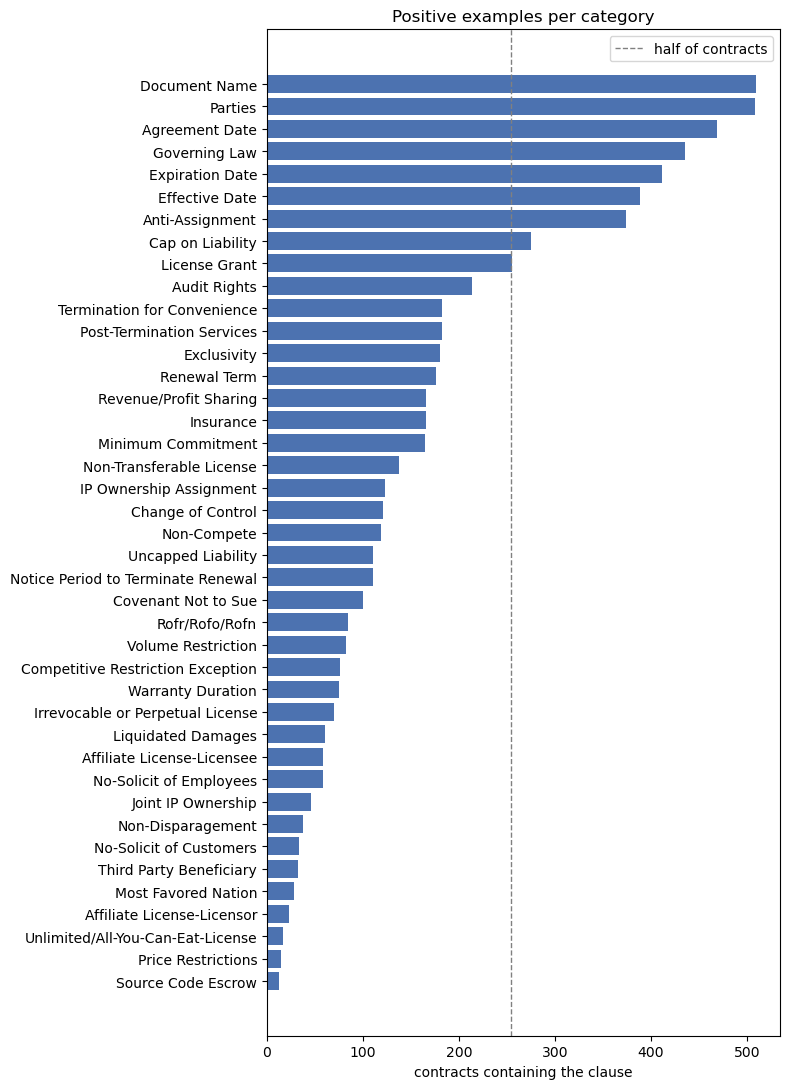

,contracts_with_clause,positive_rate,spans
category,,,
Source Code Escrow,13,0.026,66
Price Restrictions,15,0.029,27
Unlimited/All-You-Can-Eat-License,17,0.033,32
Affiliate License-Licensor,23,0.045,69
Most Favored Nation,28,0.055,38
Third Party Beneficiary,32,0.063,39
No-Solicit of Customers,34,0.067,58
Non-Disparagement,38,0.075,65
Joint IP Ownership,46,0.090,115


In [2]:
by_cat = pd.DataFrame({
    "contracts_with_clause": annotations.groupby("category")["has_annotation"].sum(),
    "positive_rate": annotations.groupby("category")["has_annotation"].mean(),
    "spans": spans.groupby("category").size(),
}).fillna(0).sort_values("contracts_with_clause")

fig, ax = plt.subplots(figsize=(8, 11))
ax.barh(by_cat.index, by_cat["contracts_with_clause"], color="#4C72B0")
ax.axvline(len(contracts) / 2, ls="--", c="grey", lw=1, label="half of contracts")
ax.set_xlabel("contracts containing the clause")
ax.set_title("Positive examples per category")
ax.legend()
plt.tight_layout()
plt.show()
by_cat.sort_values("positive_rate").round(3)

## 2. Class imbalance

overall positive rate: 32.1%
categories under 10% positive: 9 of 41
categories over 50% positive:  9
most/least common ratio: 39x


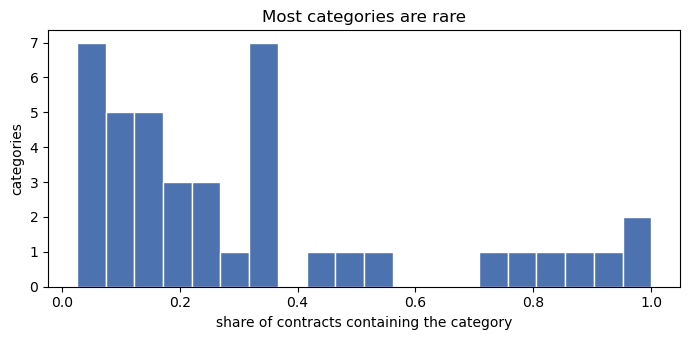

In [3]:
rate = by_cat["positive_rate"]
print(f"overall positive rate: {annotations['has_annotation'].mean():.1%}")
print(f"categories under 10% positive: {(rate < 0.10).sum()} of {len(rate)}")
print(f"categories over 50% positive:  {(rate > 0.50).sum()}")
print(f"most/least common ratio: {rate.max() / rate.min():.0f}x")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(rate, bins=20, color="#4C72B0", edgecolor="white")
ax.set_xlabel("share of contracts containing the category")
ax.set_ylabel("categories")
ax.set_title("Most categories are rare")
plt.tight_layout()
plt.show()

In [4]:
# Does the official test split look like train?
split_rate = annotations.pivot_table(index="category", columns="split", values="has_annotation", aggfunc="mean")
split_rate["gap"] = split_rate["test"] - split_rate["train"]
split_rate.reindex(split_rate["gap"].abs().sort_values(ascending=False).index).head(8).round(3)

split,test,train,gap
category,,,
Cap on Liability,0.431,0.568,-0.136
Renewal Term,0.255,0.369,-0.114
Uncapped Liability,0.127,0.241,-0.113
Effective Date,0.686,0.784,-0.098
Post-Termination Services,0.284,0.376,-0.092
Termination for Convenience,0.284,0.376,-0.092
Notice Period to Terminate Renewal,0.157,0.233,-0.077
Non-Transferable License,0.216,0.285,-0.069


## 3. Contract lengths

count      509.0
mean      7870.0
std       8365.0
min        109.0
25%       2472.0
50%       5039.0
75%      10211.0
max      47417.0
Name: n_words, dtype: float64


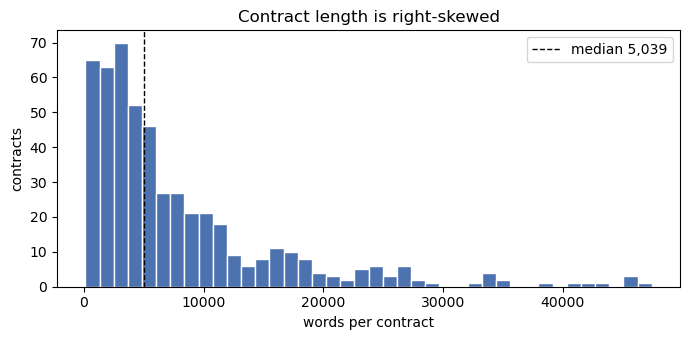

In [5]:
print(contracts["n_words"].describe().round(0))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(contracts["n_words"], bins=40, color="#4C72B0", edgecolor="white")
ax.axvline(contracts["n_words"].median(), c="k", ls="--", lw=1, label=f"median {contracts['n_words'].median():,.0f}")
ax.set_xlabel("words per contract")
ax.set_ylabel("contracts")
ax.set_title("Contract length is right-skewed")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Clause (answer span) lengths

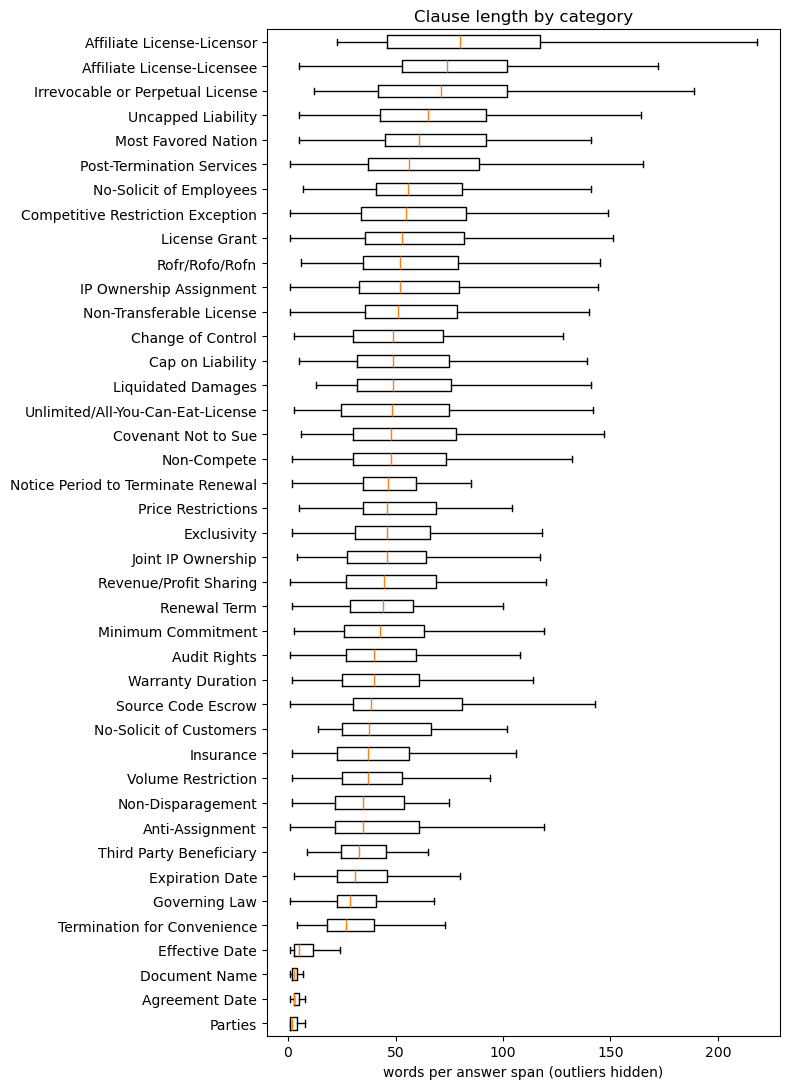

count    13809.0
mean        40.7
std         43.5
min          1.0
25%          5.0
50%         31.0
75%         57.0
max        479.0
Name: n_words, dtype: float64

In [6]:
order = spans.groupby("category")["n_words"].median().sort_values().index
fig, ax = plt.subplots(figsize=(8, 11))
ax.boxplot([spans.loc[spans["category"] == c, "n_words"] for c in order], vert=False, showfliers=False)
ax.set_yticks(range(1, len(order) + 1), order)
ax.set_xlabel("words per answer span (outliers hidden)")
ax.set_title("Clause length by category")
plt.tight_layout()
plt.show()
spans["n_words"].describe().round(1)

## 5. Chunk lengths and chunk-level imbalance

In [7]:
CHUNK_WORDS, OVERLAP = 384, 48

def chunk_bounds(text, size=CHUNK_WORDS, overlap=OVERLAP):
    """Character (start, end, n_words) of each overlapping word window."""
    words = [m.span() for m in re.finditer(r"\S+", text)]
    return [(words[i][0], words[min(i + size, len(words)) - 1][1], min(size, len(words) - i))
            for i in range(0, max(len(words) - overlap, 1), size - overlap)]

def make_chunks(size=CHUNK_WORDS, overlap=OVERLAP):
    rows = [(cid, i, s, e, n) for cid, text in zip(contracts["contract_id"], contracts["text"])
            for i, (s, e, n) in enumerate(chunk_bounds(text, size, overlap))]
    return pd.DataFrame(rows, columns=["contract_id", "chunk_index", "start", "end", "n_words"])

def label_chunks(chunks):
    """Span/chunk pairs that overlap (hit) and pairs where the span fits entirely in the chunk (contained)."""
    m = spans[["contract_id", "category", "start", "end"]].merge(chunks, on="contract_id", suffixes=("", "_c"))
    hit = m[(m["start"] < m["end_c"]) & (m["end"] > m["start_c"])]
    contained = m[(m["start"] >= m["start_c"]) & (m["end"] <= m["end_c"])]
    return hit, contained

span_keys = ["contract_id", "category", "start", "end"]
chunks = make_chunks()
hit, contained = label_chunks(chunks)
print(f"chunks: {len(chunks):,}  per contract: median {chunks.groupby('contract_id').size().median():.0f}, "
      f"max {chunks.groupby('contract_id').size().max()}")
print(f"chunks shorter than the window (contract tails): {(chunks['n_words'] < CHUNK_WORDS).mean():.1%}")

chunks: 12,105  per contract: median 15, max 141
chunks shorter than the window (contract tails): 4.2%


chunks with no label at all: 52.2%
median category positive rate: contract level 23.4%, chunk level 1.86%
answer spans not fully inside any chunk: 3.53%


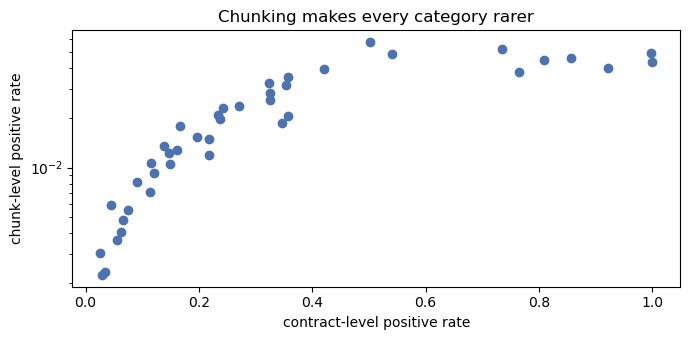

In [8]:
chunk_pos = hit.groupby("category")[["contract_id", "chunk_index"]].apply(lambda d: len(d.drop_duplicates())) / len(chunks)
labelled_chunks = hit[["contract_id", "chunk_index"]].drop_duplicates()
split_spans = 1 - len(contained[span_keys].drop_duplicates()) / len(spans[span_keys].drop_duplicates())

print(f"chunks with no label at all: {1 - len(labelled_chunks) / len(chunks):.1%}")
print(f"median category positive rate: contract level {rate.median():.1%}, chunk level {chunk_pos.median():.2%}")
print(f"answer spans not fully inside any chunk: {split_spans:.2%}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.scatter(rate, chunk_pos.reindex(rate.index), color="#4C72B0")
ax.set_xlabel("contract-level positive rate")
ax.set_ylabel("chunk-level positive rate")
ax.set_yscale("log")
ax.set_title("Chunking makes every category rarer")
plt.tight_layout()
plt.show()

# Hand-off analyses

The sections below are for whoever picks up the next three tasks: **data splitting** (section 6), **chunking** (section 7) and **the baseline** (section 8).
Section 9 combines everything into one table per category and a suggested shortlist of focus categories.

## 6. For data splitting

types with no test contracts: ['MANUFACTUR', 'COLLABORATION', 'AFFILIATE']


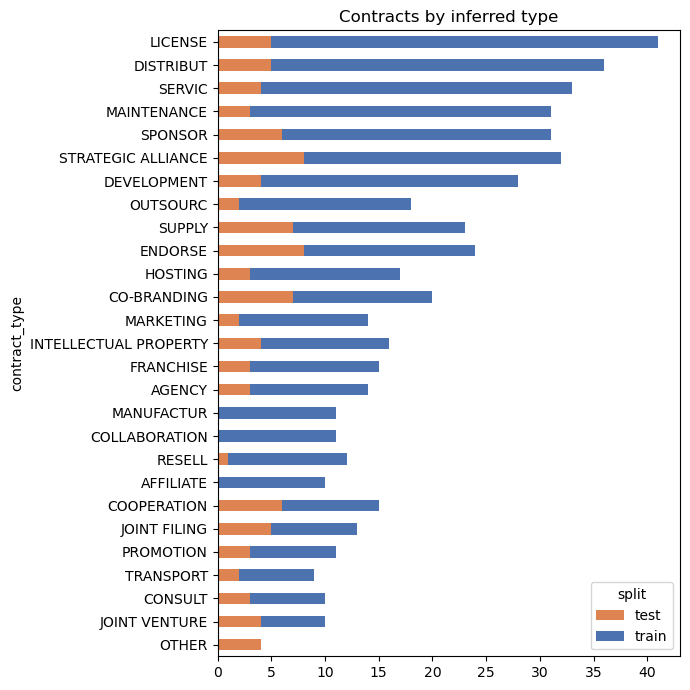

In [9]:
# Contract type is not a field in CUAD; infer it from the name at the end of contract_id
TYPES = ["LICENSE", "DISTRIBUT", "RESELL", "FRANCHISE", "SPONSOR", "ENDORSE", "PROMOTION", "MARKETING",
         "STRATEGIC ALLIANCE", "COLLABORATION", "COOPERATION", "JOINT VENTURE", "OUTSOURC", "SUPPLY",
         "MANUFACTUR", "SERVIC", "MAINTENANCE", "HOSTING", "CONSULT", "AGENCY", "DEVELOPMENT", "TRANSPORT",
         "JOINT FILING", "INTELLECTUAL PROPERTY", "CO-BRANDING", "AFFILIATE"]
contracts["contract_type"] = contracts["contract_id"].map(
    lambda cid: next((t for t in TYPES if t in cid.upper().split("EX-")[-1]), "OTHER"))

types = pd.crosstab(contracts["contract_type"], contracts["split"]).sort_values("train", ascending=False)
print("types with no test contracts:", list(types.index[types["test"] == 0]))
types.plot.barh(stacked=True, figsize=(7, 7), color=["#DD8452", "#4C72B0"], title="Contracts by inferred type")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
labels_per_contract = annotations.groupby("contract_id")["has_annotation"].sum()
print(labels_per_contract.describe().round(1))

# What a 20% validation carve-out from train would hold, per category
VAL_SHARE = 0.20
support = annotations.pivot_table(index="category", columns="split", values="has_annotation", aggfunc="sum")
support["expected_val"] = (support["train"] * VAL_SHARE).round(1)
thin = support[support["expected_val"] < 10].sort_values("expected_val")
print(f"\ncategories with fewer than 10 expected validation positives: {len(thin)}")
thin

count    509.0
mean      13.1
std        5.9
min        2.0
25%        9.0
50%       13.0
75%       17.0
max       32.0
Name: has_annotation, dtype: float64

categories with fewer than 10 expected validation positives: 12


split,test,train,expected_val
category,,,
Source Code Escrow,1,12,2.4
Unlimited/All-You-Can-Eat-License,3,14,2.8
Price Restrictions,0,15,3.0
Affiliate License-Licensor,6,17,3.4
Most Favored Nation,3,25,5.0
Third Party Beneficiary,6,26,5.2
No-Solicit of Customers,7,27,5.4
Non-Disparagement,7,31,6.2
Joint IP Ownership,7,39,7.8


## 7. For chunking

In [11]:
# Trade-off between chunk size, labels cut at chunk boundaries, and empty chunks
sweep = []
for size in [128, 256, 384, 512]:
    ch = make_chunks(size, size // 8)
    h, c = label_chunks(ch)
    sweep.append({
        "chunk_words": size,
        "overlap": size // 8,
        "chunks": len(ch),
        "spans_cut": 1 - len(c[span_keys].drop_duplicates()) / len(spans[span_keys].drop_duplicates()),
        "unlabelled_chunks": 1 - len(h[["contract_id", "chunk_index"]].drop_duplicates()) / len(ch),
    })
sweep = pd.DataFrame(sweep)
sweep[["spans_cut", "unlabelled_chunks"]] = (sweep[["spans_cut", "unlabelled_chunks"]] * 100).round(1)
sweep.rename(columns={"spans_cut": "spans_cut_%", "unlabelled_chunks": "unlabelled_chunks_%"})

,chunk_words,overlap,chunks,spans_cut_%,unlabelled_chunks_%
0,128,16,35939,22.6,71.6
1,256,32,18060,8.2,60.3
2,384,48,12105,3.5,52.2
3,512,64,9119,1.9,45.2


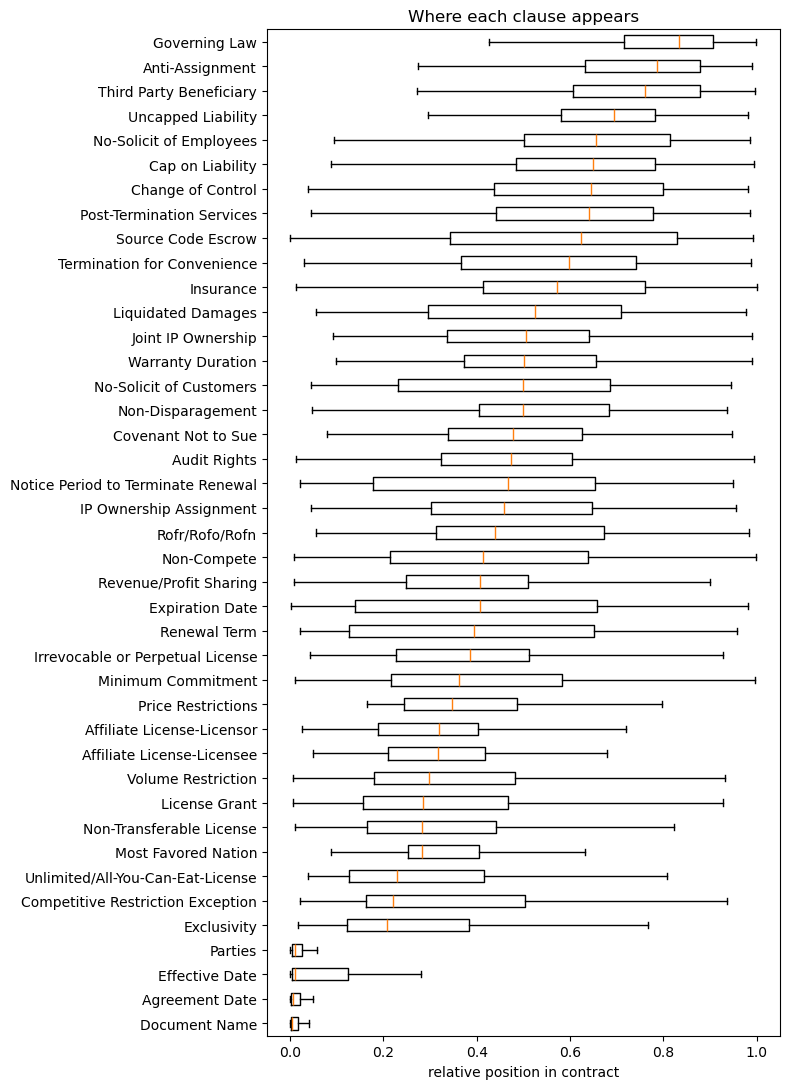

share of spans cut by a 384-word chunk boundary, worst categories:
category
IP Ownership Assignment             0.079
Affiliate License-Licensee          0.087
Uncapped Liability                  0.090
Irrevocable or Perpetual License    0.091
Non-Disparagement                   0.092
Post-Termination Services           0.093
Source Code Escrow                  0.106
Affiliate License-Licensor          0.116


In [12]:
# Where in the contract each clause starts (0 = first character, 1 = last)
spans["rel_pos"] = spans["start"] / spans["contract_id"].map(contracts.set_index("contract_id")["n_chars"])
order = spans.groupby("category")["rel_pos"].median().sort_values().index
fig, ax = plt.subplots(figsize=(8, 11))
ax.boxplot([spans.loc[spans["category"] == c, "rel_pos"] for c in order], vert=False, showfliers=False)
ax.set_yticks(range(1, len(order) + 1), order)
ax.set_xlabel("relative position in contract")
ax.set_title("Where each clause appears")
plt.tight_layout()
plt.show()

cut = spans.merge(contained[span_keys].drop_duplicates().assign(fits=True), on=span_keys, how="left")
print("share of spans cut by a 384-word chunk boundary, worst categories:")
print((1 - cut.groupby("category")["fits"].count() / cut.groupby("category").size()).sort_values().tail(8).round(3).to_string())

## 8. For the baseline

In [13]:
import json
cats = pd.DataFrame(json.load(open("../data/processed/categories.json"))).set_index("name")
cats["task"] = cats["answer_format"].fillna("").map(
    lambda f: "yes/no clause" if f.startswith("Yes/No") or f == "" else "extract value")
print(cats["task"].value_counts().to_string())
cats.loc[cats["task"] == "extract value", ["answer_format"]]

task
yes/no clause    32
extract value     9


,answer_format
name,
Document Name,Contract Name
Parties,Entity or individual names
Agreement Date,Date (mm/dd/yyyy)
Effective Date,Date (mm/dd/yyyy)
Expiration Date,Date (mm/dd/yyyy) / Perpetual
Renewal Term,[Successive] number of years/months / Perpetual
Notice Period to Terminate Renewal,Number of days/months/year(s)
Governing Law,"Name of a US State / non-US Province, Country"
Warranty Duration,Number of months or years


In [14]:
# The same text is often labelled with two categories, so the task is multi-label, not multi-class
s = spans[span_keys].reset_index()
pairs = s.merge(s, on="contract_id")
pairs = pairs[(pairs["category_x"] < pairs["category_y"]) &
              (pairs["start_x"] < pairs["end_y"]) & (pairs["end_x"] > pairs["start_y"])]
overlap = pairs.groupby(["category_x", "category_y"]).size().rename("overlapping_spans").sort_values(ascending=False)
in_pair = pd.concat([pairs["index_x"], pairs["index_y"]]).nunique()
print(f"spans that overlap a span from another category: {in_pair / len(spans):.1%}")
overlap.head(12).to_frame()

spans that overlap a span from another category: 22.8%


,,overlapping_spans
category_x,category_y,
Agreement Date,Effective Date,265
License Grant,Non-Transferable License,216
Irrevocable or Perpetual License,License Grant,155
Cap on Liability,Uncapped Liability,141
Exclusivity,License Grant,113
Notice Period to Terminate Renewal,Renewal Term,105
Affiliate License-Licensee,License Grant,74
Effective Date,Expiration Date,61
Affiliate License-Licensor,License Grant,48


## 9. Category profile and suggested shortlist

One row per category with everything above. It is also saved to `data/eda/category_profile.csv` so the next tasks can load it without re-running this notebook.

The shortlist rule is a starting point, not a decision:
* at least **80 train contracts** with the clause, so a 20% validation split still holds about 16;
* at least **20 test contracts**, so test recall moves by at most 5 points per contract;
* a **yes/no clause** category, so one model type and one metric cover the whole set.
  Metadata categories (names, dates, governing law, terms) are span-extraction problems and are better handled separately, or with rules.

In [15]:
from pathlib import Path

partner = overlap.reset_index()
partner = pd.concat([partner.rename(columns={"category_x": "category", "category_y": "most_overlaps_with"}),
                     partner.rename(columns={"category_y": "category", "category_x": "most_overlaps_with"})])
partner = partner.sort_values("overlapping_spans", ascending=False).drop_duplicates("category").set_index("category")

profile = pd.DataFrame({
    "task": cats["task"],
    "train_contracts": support["train"],
    "test_contracts": support["test"],
    "expected_val_contracts": support["expected_val"],
    "positive_rate": rate,
    "chunk_positive_rate": chunk_pos,
    "spans_per_positive_contract": spans.groupby("category").size() / by_cat["contracts_with_clause"],
    "median_span_words": spans.groupby("category")["n_words"].median(),
    "median_rel_position": spans.groupby("category")["rel_pos"].median(),
    "most_overlaps_with": partner["most_overlaps_with"],
}).round(3)
profile["shortlist"] = ((profile["train_contracts"] >= 80) & (profile["test_contracts"] >= 20)
                        & (profile["task"] == "yes/no clause"))
profile = profile.sort_values(["shortlist", "train_contracts"], ascending=False)

Path("../data/eda").mkdir(exist_ok=True)
profile.rename_axis("category").to_csv("../data/eda/category_profile.csv")
print(f"shortlisted: {profile['shortlist'].sum()} of {len(profile)}")
profile

shortlisted: 14 of 41


,task,train_contracts,test_contracts,expected_val_contracts,positive_rate,chunk_positive_rate,spans_per_positive_contract,median_span_words,median_rel_position,most_overlaps_with,shortlist
Anti-Assignment,yes/no clause,302,72,60.4,0.735,0.052,1.749,35.0,0.787,Change of Control,True
Cap on Liability,yes/no clause,231,44,46.2,0.540,0.049,2.444,49.0,0.650,Uncapped Liability,True
License Grant,yes/no clause,205,50,41.0,0.501,0.058,3.047,53.0,0.284,Non-Transferable License,True
Audit Rights,yes/no clause,176,38,35.2,0.420,0.040,3.005,40.0,0.474,Post-Termination Services,True
Post-Termination Services,yes/no clause,153,29,30.6,0.358,0.035,2.473,56.5,0.641,Rofr/Rofo/Rofn,True
Termination for Convenience,yes/no clause,153,29,30.6,0.358,0.020,1.346,27.0,0.598,Expiration Date,True
Exclusivity,yes/no clause,147,33,29.4,0.354,0.032,2.278,46.0,0.208,License Grant,True
Insurance,yes/no clause,134,32,26.8,0.326,0.026,3.373,37.0,0.572,Post-Termination Services,True
Minimum Commitment,yes/no clause,133,32,26.6,0.324,0.033,2.570,43.0,0.361,Exclusivity,True
Revenue/Profit Sharing,yes/no clause,131,35,26.2,0.326,0.028,2.518,44.5,0.406,Minimum Commitment,True


## Findings

1. **Labels are very imbalanced.** Only 32% of contract×category pairs are positive, and 18 of the 41 categories appear in fewer than 1 in 5 contracts. *Source Code Escrow*, *Price Restrictions* and *Unlimited License* appear in only 13–17 contracts each, a 39x spread from the most to the least common category. Report per-category precision/recall (or AUPR), not accuracy.
2. **Chunking makes the imbalance much worse.** At 384 words per chunk, the median category falls from 23% of contracts to about 1.9% of chunks, and 52% of chunks carry no label at all.
3. **Clause length depends heavily on category.** Names and dates are 2–5 words. License and liability clauses have medians of 65–80 words, and the longest spans run to about 480 words.
4. **Contract length is heavily skewed.** Contracts run from 109 to 47,417 words, with a median of about 5,000. That is 15 chunks for the median contract and 141 for the longest.
5. **The official test split is less densely labelled than train.** 29 of 41 categories are rarer in test (29.7% vs 32.6% overall). Three contract types (manufacturing, collaboration, affiliate) have no test contracts at all.
6. **Labels overlap.** 22.8% of spans overlap a span from another category (for example License Grant with Non-Transferable License, or Cap on Liability with Uncapped Liability), so this is a multi-label problem.

## Hand-off notes

**Data splitting**
* Split by `contract_id`, never by chunk, or chunks from one contract leak across splits.
* Keep the official test set untouched and carve validation out of the 408 train contracts.
* Stratify on which categories each contract has (multi-label stratification, for example `iterative-stratification`). A random 20% split leaves 12 categories with fewer than 10 validation positives.
* The duplicate ADUROBIOTECH contract is already dropped here; drop it in the split too.

**Chunking**
* 384 words (about 512 tokens) with 48 words of overlap cuts 3.5% of spans; 256 words cuts 8.2% and 128 words cuts 22.6% (see the chunk-size table in section 7).
* Label a chunk positive if it overlaps a span, not only if it fully contains one. Long license and liability clauses are the ones that get cut.
* Metadata clauses (names, dates) sit at the start of the contract, while Governing Law and Anti-Assignment sit near the end (section 7), so position is a useful feature.

**Baseline**
* Start with the 14 shortlisted yes/no categories in `data/eda/category_profile.csv` (`shortlist == True`). Each has at least 95 train and at least 22 test contracts.
* Treat it as multi-label, and downsample unlabelled chunks or use class weights.
* Handle the 9 extract-value categories (names, dates, governing law, terms) separately. They are span extraction, not classification.

Exact numbers are printed in the cells above; re-run the notebook after changing the data preparation.